In [1]:
import matplotlib as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/matthewclinton/Downloads/Virtual Patient Models_Dataset.csv")

df['balance_single'] = df['balance_single'].replace("test non realizable", np.nan)

#fix incorrect and placeholder values
social_cols = [
    "social_phone", 
    "social_visits", 
    "social_skype", 
    "social_text", 
    "social_calls"
]


df[social_cols] = df[social_cols].replace(999, np.nan)

#Forward fill
cols_to_fill = [
    "house_suitable_professional",
    "house_suitable_participant",
    "stairs_number"
]


df = df.sort_values(["part_id", "clinical_visit"])

df[cols_to_fill] = (
    df
    .groupby("part_id")[cols_to_fill]
    .ffill()
)


detailed_nans = df[['part_id']].join(df.iloc[:, 1:]).melt(id_vars='part_id')
detailed_nans = detailed_nans[detailed_nans['value'].isna()]

print("Detailed NaNs (part_id and variable):")
print(detailed_nans[['part_id', 'variable']])

total_nans = df.isna().sum().sum()
print(f"\nTotal NaN values: {total_nans}")

total_values = df.drop(columns=['part_id']).size
print(f"Total cells (excluding part_id): {total_values}")

percent = (total_nans / total_values) * 100
print(f"Percentage of missing data: {round(percent, 4)}%")

Detailed NaNs (part_id and variable):
      part_id                      variable
698      2584  comorbidities_most_important
1650     1088                balance_single
1651     1088                balance_single
1652     1088                balance_single
1653     1088                balance_single
...       ...                           ...
5009     2092                   social_text
5027     2584                   social_text
5028     2584                   social_text
5936     2089              activity_regular
5951     2097              activity_regular

[230 rows x 2 columns]

Total NaN values: 230
Total cells (excluding part_id): 6786
Percentage of missing data: 3.3893%


In [4]:
#exclude selected columns to keep the link to the patient
exclude_cols = ['part_id', 'clinical_visit', 'q_date']
mask_cols = [col for col in df.columns if col not in exclude_cols]

#only removing existing data
valid_coordinates = []
for col in mask_cols:

    valid_indices = df[df[col].notna()].index.tolist()
    for row_idx in valid_indices:
        valid_coordinates.append((row_idx, col))

#30% missingness
np.random.seed(42)
n_to_mask = int(0.3 * len(valid_coordinates))
mask_choice_indices = np.random.choice(len(valid_coordinates), n_to_mask, replace=False)
masked_cells = [valid_coordinates[i] for i in mask_choice_indices]


df_missing = df.copy()
for i in mask_choice_indices:
    row, col = valid_coordinates[i]
    df_missing.loc[row, col] = np.nan

print(f"Total valid cells identified: {len(valid_coordinates)}")
print(f"Total cells masked: {n_to_mask}")

total_nans = df_missing.isna().sum().sum()
print(f"Total NaN values: {total_nans}")
total_values = df_missing.drop(columns=['part_id']).size
print(total_values)
print((total_nans/total_values)*100)
numeric_cols = df_missing.select_dtypes(include=np.number).columns

Total valid cells identified: 6322
Total cells masked: 1896
Total NaN values: 2126
6786
31.329207191276158


In [5]:
#10% missingness dataset

exclude_cols = ['part_id', 'clinical_visit', 'q_date']
mask_cols = [col for col in df.columns if col not in exclude_cols]

valid_coordinates_10 = []

for col in mask_cols:
    valid_indices = df[df[col].notna()].index.tolist()
    for row_idx in valid_indices:
        valid_coordinates_10.append((row_idx, col))

np.random.seed(123)
n_to_mask_10 = int(0.10 * len(valid_coordinates_10))

mask_choice_indices_10 = np.random.choice(
    len(valid_coordinates_10),
    n_to_mask_10,
    replace=False
)

#store masked cells
masked_cells_10 = [valid_coordinates_10[i] for i in mask_choice_indices_10]

df_missing_10 = df.copy()

for row, col in masked_cells_10:
    df_missing_10.loc[row, col] = np.nan

# 5. Verification
print("----- 10% Missingness Dataset -----")
print(f"Total valid cells identified: {len(valid_coordinates_10)}")
print(f"Total cells masked: {n_to_mask_10}")

total_nans_10 = df_missing_10.isna().sum().sum()
print(f"Total NaN values: {total_nans_10}")

total_values_10 = df_missing_10.drop(columns=['part_id']).size
print(f"Total values (excluding ID column): {total_values_10}")

print(f"Percent missing: {(total_nans_10 / total_values_10) * 100:.2f}%")

numeric_cols_10 = df_missing_10.select_dtypes(include=np.number).columns

----- 10% Missingness Dataset -----
Total valid cells identified: 6322
Total cells masked: 632
Total NaN values: 862
Total values (excluding ID column): 6786
Percent missing: 12.70%


In [6]:
#Bad 20% missingness

valid_coordinates_20_456 = []

for col in mask_cols:
    valid_indices = df[df[col].notna()].index.tolist()
    for row_idx in valid_indices:
        valid_coordinates_20_456.append((row_idx, col))

np.random.seed(456)
n_to_mask_20_456 = int(0.20 * len(valid_coordinates_20_456))

mask_choice_indices_20_456 = np.random.choice(
    len(valid_coordinates_20_456),
    n_to_mask_20_456,
    replace=False
)

masked_cells_20_456 = [valid_coordinates_20_456[i] for i in mask_choice_indices_20_456]

df_missing_20_456 = df.copy()

for row, col in masked_cells_20_456:
    df_missing_20_456.loc[row, col] = np.nan

print("20% Missingness Dataset")
print(f"Total valid cells identified: {len(valid_coordinates_20_456)}")
print(f"Total cells masked: {n_to_mask_20_456}")

total_nans_20_456 = df_missing_20_456.isna().sum().sum()
print(f"Total NaN values: {total_nans_20_456}")

total_values_20_456 = df_missing_20_456.drop(columns=['part_id']).size
print(f"Total values (excluding ID column): {total_values_20_456}")

print(f"Percent missing: {(total_nans_20_456 / total_values_20_456) * 100:.2f}%")

numeric_cols_20_456 = df_missing_20_456.select_dtypes(include=np.number).columns

20% Missingness Dataset
Total valid cells identified: 6322
Total cells masked: 1264
Total NaN values: 1494
Total values (excluding ID column): 6786
Percent missing: 22.02%


In [7]:
#20% missingness dataset
valid_coordinates_20 = []

for col in mask_cols:
    valid_indices = df[df[col].notna()].index.tolist()
    for row_idx in valid_indices:
        valid_coordinates_20.append((row_idx, col))

np.random.seed(6)
n_to_mask_20 = int(0.20 * len(valid_coordinates_20))

mask_choice_indices_20 = np.random.choice(
    len(valid_coordinates_20),
    n_to_mask_20,
    replace=False
)

#store masked cells
masked_cells_20 = [valid_coordinates_20[i] for i in mask_choice_indices_20]

df_missing_20 = df.copy()

for row, col in masked_cells_20:
    df_missing_20.loc[row, col] = np.nan

print("----- 20% Missingness Dataset -----")
print(f"Total valid cells identified: {len(valid_coordinates_20)}")
print(f"Total cells masked: {n_to_mask_20}")

total_nans_20 = df_missing_20.isna().sum().sum()
print(f"Total NaN values: {total_nans_20}")

total_values_20 = df_missing_20.drop(columns=['part_id']).size
print(f"Total values (excluding ID column): {total_values_20}")

print(f"Percent missing: {(total_nans_20 / total_values_20) * 100:.2f}%")

numeric_cols_20 = df_missing_20.select_dtypes(include=np.number).columns

----- 20% Missingness Dataset -----
Total valid cells identified: 6322
Total cells masked: 1264
Total NaN values: 1494
Total values (excluding ID column): 6786
Percent missing: 22.02%


In [ ]:
import pandas as pd
import numpy as np

#patient mean imputation
def run_unified_patient_imputation(df_masked, df_ground_truth, masked_cells):
    df_imputed = df_masked.copy()
    
    numeric_cols = df_masked.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_masked.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    def impute_group(group):
        for col in numeric_cols:
            if group[col].isna().any():
                m_val = group[col].mean()
                if not np.isnan(m_val):
                    group[col] = group[col].fillna(m_val)
        
        for col in categorical_cols:
            if group[col].isna().any():
                mode_vals = group[col].mode()
                if not mode_vals.empty:
                    group[col] = group[col].fillna(mode_vals[0])
        return group

    df_imputed = df_imputed.groupby("part_id", group_keys=False).apply(impute_group)

    #with 0 values, use global mean
    df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_masked[numeric_cols].mean())
    for col in categorical_cols:
        global_mode = df_masked[col].mode()
        if not global_mode.empty:
            df_imputed[col] = df_imputed[col].fillna(global_mode[0])

    #evaluation
    nmae_errors = []
    cat_hits, cat_total = 0, 0
    col_ranges = df_ground_truth[numeric_cols].max() - df_ground_truth[numeric_cols].min()

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_imputed.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs(true_val - imp_val) / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)
    
    return {
        "NMAE": avg_nmae,
        "Accuracy": avg_acc,
        "Unified_Score": unified_score,
        "Clean_DF": df_imputed
    }

#Storage of imputed datasets
mean_summary = {}
experiments = [
    (df_missing_10,      df, masked_cells_10,      "10%"),
    (df_missing_20,      df, masked_cells_20,      "20%"),
    (df_missing_20_456,  df, masked_cells_20_456,  "20% (seed 456)"),
    (df_missing,         df, masked_cells,         "30%")
]

print("Running Patient-Mean Imputations...")

for d_m, d_g, m_c, label in experiments:
    res = run_unified_patient_imputation(d_m, d_g, m_c)
    
    mean_summary[label] = res["Unified_Score"]
    
    if label == "10%":
        df_mean_10 = res["Clean_DF"]
    elif label == "20%":
        df_mean_20 = res["Clean_DF"]
    elif label == "20% (seed 456)":
        df_mean_20_456 = res["Clean_DF"]
    else:
        df_mean_30 = res["Clean_DF"]
        
    print(f"Mean {label} -> Unified Score: {res['Unified_Score']:.4f} (NMAE: {res['NMAE']:.4f})")

print("\nSuccess: df_mean_10, df_mean_20, df_mean_20_456, and df_mean_30 are now stored.")

Running Patient-Mean Imputations...
Mean 10% -> Unified Score: 0.9083 (NMAE: 0.0468)
Mean 20% -> Unified Score: 0.9077 (NMAE: 0.0708)
Mean 20% (seed 456) -> Unified Score: 0.8884 (NMAE: 0.0683)
Mean 30% -> Unified Score: 0.9025 (NMAE: 0.0805)

Success: df_mean_10, df_mean_20, df_mean_20_456, and df_mean_30 are now stored.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
#Set-up
def run_stochastic_regression_100(df_masked, df_ground_truth, masked_cells):
    df_temp = df_masked.copy().sort_values(['part_id', 'clinical_visit'])
    
    numeric_cols = df_temp.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_temp.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        valid_mask = df_temp[col].notna()
        df_temp.loc[valid_mask, col] = le.fit_transform(df_temp.loc[valid_mask, col]).astype(float)
        encoders[col] = le

    target_cols = list(numeric_cols) + list(categorical_cols)

    def impute_stochastic_logic(group):
        for col in target_cols:
            if group[col].isna().any():
                valid = group[group[col].notna()]
                
                if len(valid) >= 2:
                    model = LinearRegression().fit(valid[['clinical_visit']], valid[col])
                    preds_base = model.predict(group.loc[group[col].isna(), ['clinical_visit']])

                    residuals = valid[col] - model.predict(valid[['clinical_visit']])
                    sigma = np.std(residuals) if len(residuals) > 1 else 0.1
                    
                    iterations = 100
                    stochastic_results = []
                    for _ in range(iterations):
                        noise = np.random.normal(0, sigma, size=len(preds_base))
                        stochastic_results.append(preds_base + noise)
                    
                    final_preds = np.mean(stochastic_results, axis=0)

                    if col in categorical_cols:
                        final_preds = np.round(final_preds)

                    group.loc[group[col].isna(), col] = np.clip(final_preds, df_temp[col].min(), df_temp[col].max())
                else:
                    m_val = group[col].mean()
                    if not np.isnan(m_val):
                        group[col] = group[col].fillna(round(m_val) if col in categorical_cols else m_val)
        return group

    df_imputed = df_temp.groupby("part_id", group_keys=False).apply(impute_stochastic_logic)
    
    for col in target_cols:
        global_val = df_temp[col].mean()
        df_imputed[col] = df_imputed[col].fillna(round(global_val) if col in categorical_cols else global_val)

    for col in categorical_cols:
        le = encoders[col]
        df_imputed[col] = le.inverse_transform(df_imputed[col].astype(int))

#Evaluation
    nmae_errors = []
    cat_hits, cat_total = 0, 0
    col_ranges = df_ground_truth[numeric_cols].max() - df_ground_truth[numeric_cols].min()

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_imputed.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            abs_err = abs(true_val - imp_val)
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs_err / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    
    return {
        "NMAE": avg_nmae,
        "Accuracy": avg_acc,
        "Unified_Score": ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5),
        "Clean_DF": df_imputed
    }

#Storage and Exectution
stochastic_summary = {}
experiments = [
    (df_missing_10, df, masked_cells_10, "10%"),
    (df_missing_20, df, masked_cells_20, "20%"),
    (df_missing_20_456, df, masked_cells_20_456, "20% (seed 456)"),
    (df_missing,    df, masked_cells,    "30%")
]

print("Running Stochastic Regression Imputations...")

for d_m, d_g, m_c, label in experiments:
    res = run_stochastic_regression_100(d_m, d_g, m_c)
    stochastic_summary[label] = res["Unified_Score"]
    
    if label == "10%": df_stochastic_10 = res["Clean_DF"]
    elif label == "20%": df_stochastic_20 = res["Clean_DF"]
    elif label == "20% (seed 456)": df_stochastic_20_456 = res["Clean_DF"]
    else: df_stochastic_30 = res["Clean_DF"]
        
    print(f"Stochastic {label} -> Unified Score: {res['Unified_Score']:.4f} (Acc: {res['Accuracy']:.4f})")

Running Stochastic Regression Imputations...
Stochastic 10% -> Unified Score: 0.9097 (Acc: 0.8705)
Stochastic 20% -> Unified Score: 0.8986 (Acc: 0.8707)
Stochastic 20% (seed 456) -> Unified Score: 0.8925 (Acc: 0.8535)
Stochastic 30% -> Unified Score: 0.9043 (Acc: 0.8908)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

#K-Nearest Neighbour imputation
def run_knn_unified_imputation(df_masked, df_ground_truth, masked_cells):
    df_working = df_masked.copy()
    
    numeric_cols = df_masked.select_dtypes(include=[np.number]).columns.difference(['part_id'])
    categorical_cols = df_masked.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    #Encode categorical variables
    le_dicts = {}
    for col in categorical_cols:
        le = LabelEncoder()
        temp_series = df_working[col].fillna('Missing').astype(str)
        df_working[col] = le.fit_transform(temp_series)
        df_working.loc[temp_series == 'Missing', col] = np.nan
        le_dicts[col] = le

#scaling
    scaler = StandardScaler()
    all_features = numeric_cols.tolist() + categorical_cols.tolist()
    df_working[all_features] = scaler.fit_transform(df_working[all_features])

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    imputed_matrix = imputer.fit_transform(df_working[all_features])
    df_working[all_features] = scaler.inverse_transform(imputed_matrix)

    for col in categorical_cols:
        df_working[col] = df_working[col].round().astype(int).clip(0, len(le_dicts[col].classes_) - 1)
        df_working[col] = le_dicts[col].inverse_transform(df_working[col])

    #Evaluation
    nmae_errors = []
    cat_hits, cat_total = 0, 0
    col_ranges = df_ground_truth[numeric_cols].max() - df_ground_truth[numeric_cols].min()

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_working.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs(true_val - imp_val) / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)

    return {
        "NMAE": avg_nmae,
        "Accuracy": avg_acc,
        "Unified_Score": unified_score,
        "Clean_DF": df_working
    }

#Execution
knn_summary = {}

experiments = [
    (df_missing_10, masked_cells_10, "10%"), 
    (df_missing_20, masked_cells_20, "20%"), 
    (df_missing,    masked_cells,    "30%")
]

for d_m, m_c, label in experiments:
    res = run_knn_unified_imputation(d_m, df, m_c)
    
    knn_summary[label] = res["Unified_Score"]
    
    if label == "10%":
        df_knn_10 = res["Clean_DF"]
    elif label == "20%":
        df_knn_20 = res["Clean_DF"]
    else:
        df_knn_30 = res["Clean_DF"]
        
    print(f"KNN {label}: Unified Score: {res['Unified_Score']:.4f} NMAE: {res['NMAE']:.4f} Accuracy: {res['Accuracy']:.2%}")

KNN 10% -> Unified Score: 0.8609
KNN 20% -> Unified Score: 0.8529
KNN 30% -> Unified Score: 0.8514

Success: df_knn_10, df_knn_20, and df_knn_30 are now stored in memory.


In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def run_enhanced_experiment(df_masked, df_ground_truth, name):
    df_imputed = df_masked.copy()
    numeric_cols = df_masked.select_dtypes(include=[np.number]).columns.difference(['part_id'])
    categorical_cols = df_masked.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    def impute_patient(group):
        for col in numeric_cols:
            if group[col].isna().any():
                group[col] = group[col].fillna(group[col].mean())
        for col in categorical_cols:
            if group[col].isna().any():
                mode_val = group[col].mode()
                if not mode_val.empty:
                    group[col] = group[col].fillna(mode_val[0])
        return group

    df_imputed = df_imputed.groupby("part_id", group_keys=False).apply(impute_patient)
    
    df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_ground_truth[numeric_cols].mean())
    df_imputed[categorical_cols] = df_imputed[categorical_cols].fillna(df_ground_truth[categorical_cols].mode().iloc[0])

    nmae_values = []
    for col in numeric_cols:
        mask = df_masked[col].isna() & df_ground_truth[col].notna()
        if mask.any():
            y_true = df_ground_truth.loc[mask, col]
            y_pred = df_imputed.loc[mask, col]
            
            col_range = df_ground_truth[col].max() - df_ground_truth[col].min()
            if col_range == 0: col_range = 1
            
            col_mae = mean_absolute_error(y_true, y_pred)
            nmae_values.append(col_mae / col_range)

    avg_nmae = np.mean(nmae_values) if nmae_values else np.nan

    cat_accuracies = []
    for col in categorical_cols:
        mask = df_masked[col].isna() & df_ground_truth[col].notna()
        if mask.any():
            acc = (df_ground_truth.loc[mask, col] == df_imputed.loc[mask, col]).mean()
            cat_accuracies.append(acc)

    avg_accuracy = np.mean(cat_accuracies) if cat_accuracies else np.nan


    numeric_utility = (1 - avg_nmae) if not np.isnan(avg_nmae) else 0
    cat_utility = avg_accuracy if not np.isnan(avg_accuracy) else 0
    #50/50 weighting
    combined_score = (numeric_utility * 0.5) + (cat_utility * 0.5)

    return {
        "Dataset": name,
        "Scaled_MAE_NMAE": round(avg_nmae, 4),
        "Categorical_Acc": round(avg_accuracy, 4),
        "Combined_Quality": round(combined_score, 4)
    }

#Execution
results = []
experiments = [(df_missing_10, "10%"), (df_missing_20, "20%"), (df_missing, "30%")]

for dataset, label in experiments:
    results.append(run_enhanced_experiment(dataset, df, label))

df_results = pd.DataFrame(results)
print(df_results)

  Dataset  Scaled_MAE_NMAE  Categorical_Acc  Combined_Quality
0     10%           0.0545           0.8621            0.9038
1     20%           0.0721           0.8885            0.9082
2     30%           0.0855           0.8871            0.9008


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

#Set-up
def run_unified_trend_imputation(df_masked, df_ground_truth, masked_cells, name):
    df_temp = df_masked.copy().sort_values(['part_id', 'clinical_visit'])
    
    numeric_cols = df_temp.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_temp.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        valid_mask = df_temp[col].notna()
        df_temp.loc[valid_mask, col] = le.fit_transform(df_temp.loc[valid_mask, col]).astype(float)
        encoders[col] = le

    target_cols = list(numeric_cols) + list(categorical_cols)

    def impute_patient_trends(group):
        for col in target_cols:
            nan_mask = group[col].isna()
            if nan_mask.any():
                valid_rows = group[group[col].notna()]
                
                if len(valid_rows) >= 2:
                    model = LinearRegression()
                    model.fit(valid_rows[['clinical_visit']], valid_rows[col])
                    preds = model.predict(group.loc[nan_mask, ['clinical_visit']])
                    
                    if col in categorical_cols:
                        preds = np.round(preds)
                        
                    group.loc[nan_mask, col] = np.clip(preds, df_temp[col].min(), df_temp[col].max())
                else:
                    m_val = group[col].mean()
                    if not np.isnan(m_val):
                        group[col] = group[col].fillna(round(m_val) if col in categorical_cols else m_val)
        return group

    df_imputed = df_temp.groupby("part_id", group_keys=False).apply(impute_patient_trends)

    for col in target_cols:
        g_fill = df_temp[col].mean()
        df_imputed[col] = df_imputed[col].fillna(round(g_fill) if col in categorical_cols else g_fill)

    for col in categorical_cols:
        le = encoders[col]
        df_imputed[col] = le.inverse_transform(df_imputed[col].astype(int))

    return {
        "Level": name,
        "df_clean": df_imputed
    }

def evaluate_trend_imputation_unified(imputed_df, ground_truth_df, masked_indices, label):
   comparison_data = []
  
   numeric_cols = ground_truth_df.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
   col_ranges = ground_truth_df[numeric_cols].max() - ground_truth_df[numeric_cols].min()


   for row, col in masked_indices:
       true_val = ground_truth_df.loc[row, col]
       imp_val = imputed_df.loc[row, col]
       visit_num = imputed_df.loc[row, 'clinical_visit']
      
       if pd.isna(true_val): continue


       res = {
           'Level': label,
           'Variable': col,
           'Visit': visit_num,
           'True_Value': true_val,
           'Imputed_Value': imp_val,
           'Is_Numeric': col in numeric_cols
       }


       if col in numeric_cols:
           abs_err = abs(true_val - imp_val)
           denom = col_ranges[col] if col_ranges[col] != 0 else 1
           res['Error'] = abs_err
           res['NMAE_Component'] = abs_err / denom
       else:
           res['Correct'] = 1 if str(true_val) == str(imp_val) else 0
          
       comparison_data.append(res)
      
   return pd.DataFrame(comparison_data)


#Exectuion and storage
linear_summary = {}
experiments = [
    (df_missing_10, df, masked_cells_10, "10%"),
    (df_missing_20, df, masked_cells_20, "20%"),
    (df_missing,    df, masked_cells,    "30%")
]

print("Running Unified Linear Trend Imputations...")

for d_m, d_g, m_c, label in experiments:
    res_package = run_unified_trend_imputation(d_m, d_g, m_c, label)
    df_imputed_result = res_package['df_clean']
    
    nmae_errors = []
    cat_hits, cat_total = 0, 0
    
    numeric_cols = d_g.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    col_ranges = d_g[numeric_cols].max() - d_g[numeric_cols].min()

    for row, col in m_c:
        true_val = d_g.loc[row, col]
        imp_val = df_imputed_result.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            abs_err = abs(true_val - imp_val)
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs_err / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)
    
    linear_summary[label] = unified_score
    
    if label == "10%":
        df_linear_10 = df_imputed_result
    elif label == "20%":
        df_linear_20 = df_imputed_result
    else:
        df_linear_30 = df_imputed_result
        
    print(f"Linear Trend {label} : Unified Score: {unified_score:.4f} (NMAE: {avg_nmae:.4f}, Acc: {avg_acc:.2%})")

Running Unified Linear Trend Imputations...
Linear Trend 10% -> Unified Score: 0.9096 (NMAE: 0.0513, Acc: 87.05%)
Linear Trend 20% -> Unified Score: 0.8986 (NMAE: 0.0734, Acc: 87.07%)
Linear Trend 30% -> Unified Score: 0.9043 (NMAE: 0.0821, Acc: 89.08%)

Success: df_linear_10, df_linear_20, and df_linear_30 are now stored in memory.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder

def run_unified_poly_imputation(df_masked, df_ground_truth, masked_cells):
    df_temp = df_masked.copy().sort_values(['part_id', 'clinical_visit'])
    
    numeric_cols = df_temp.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_temp.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])
    poly = PolynomialFeatures(degree=2)

    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        valid_mask = df_temp[col].notna()
        df_temp.loc[valid_mask, col] = le.fit_transform(df_temp.loc[valid_mask, col]).astype(float)
        encoders[col] = le

    target_cols = list(numeric_cols) + list(categorical_cols)

    def impute_patient_poly(group):
        for col in target_cols:
            if group[col].isna().any():
                valid = group[group[col].notna()]
                
                if len(valid) >= 3:
                    X_train = poly.fit_transform(valid[['clinical_visit']])
                    model = LinearRegression().fit(X_train, valid[col])
                    
                    X_miss = poly.transform(group.loc[group[col].isna(), ['clinical_visit']])
                    preds = model.predict(X_miss)
                    
                    if col in categorical_cols:
                        preds = np.round(preds)
                    
                    group.loc[group[col].isna(), col] = np.clip(preds, df_temp[col].min(), df_temp[col].max())
                else:
                    m_val = group[col].mean()
                    if not np.isnan(m_val):
                        group[col] = group[col].fillna(round(m_val) if col in categorical_cols else m_val)
        return group

    df_imputed = df_temp.groupby("part_id", group_keys=False).apply(impute_patient_poly)
    
    for col in target_cols:
        g_val = df_temp[col].mean()
        if not np.isnan(g_val):
            df_imputed[col] = df_imputed[col].fillna(round(g_val) if col in categorical_cols else g_val)

    for col in categorical_cols:
        le = encoders[col]
        df_imputed[col] = le.inverse_transform(df_imputed[col].astype(int))

    #Evaluation
    nmae_errors = []
    cat_hits, cat_total = 0, 0

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_imputed.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            col_range = df_ground_truth[col].max() - df_ground_truth[col].min()
            denom = col_range if col_range != 0 else 1
            nmae_errors.append(abs(true_val - imp_val) / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)

    return {
        "Unified_Score": unified_score,
        "NMAE": avg_nmae,
        "Accuracy": avg_acc,
        "Clean_DF": df_imputed
    }

#Execution and Storage
poly_summary = {}


experiments = [
   (df_missing_10, df, masked_cells_10, "10%"),
   (df_missing_20, df, masked_cells_20, "20%"),
   (df_missing,    df, masked_cells,    "30%")
]

for d_m, d_g, m_c, label in experiments:
   res = run_unified_poly_imputation(d_m, d_g, m_c)
  
   poly_summary[label] = res["Unified_Score"]
  
   if label == "10%":
       df_poly_10 = res["Clean_DF"]
   elif label == "20%":
       df_poly_20 = res["Clean_DF"]
   else:
       df_poly_30 = res["Clean_DF"]
      
   print(f"Poly {label}: Unified: {res['Unified_Score']:.4f} (NMAE: {res['NMAE']:.4f}, Acc: {res['Accuracy']:.2%})")

Running Polynomial Trend Imputations (Degree 2)...
Poly 10% -> Unified: 0.8959 (NMAE: 0.0679, Acc: 85.97%)
Poly 20% -> Unified: 0.8822 (NMAE: 0.0888, Acc: 85.33%)
Poly 30% -> Unified: 0.8950 (NMAE: 0.0901, Acc: 88.01%)

Success: df_poly_10, df_poly_20, and df_poly_30 have been stored.


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder

def run_unified_mixed_imputation(df_masked, df_ground_truth, masked_cells, name):
    df_result = df_masked.copy().sort_values(['part_id', 'clinical_visit'])
    
    numeric_cols = df_result.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_result.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        valid_mask = df_result[col].notna()
        df_result.loc[valid_mask, col] = le.fit_transform(df_result.loc[valid_mask, col]).astype(float)
        encoders[col] = le

    target_cols = list(numeric_cols) + list(categorical_cols)

    for col in target_cols:
        if df_result[col].isna().any():
            try:
                model = smf.mixedlm(f"{col} ~ clinical_visit", df_result, groups=df_result["part_id"], missing='drop')
                fit = model.fit()
                
                nan_mask = df_result[col].isna()
                preds = fit.predict(df_result.loc[nan_mask])
                
                if col in categorical_cols:
                    preds = np.round(preds)
                
                df_result.loc[nan_mask, col] = np.clip(preds, df_result[col].min(), df_result[col].max())
            except:
                df_result[col] = df_result.groupby("part_id")[col].transform(
                    lambda x: x.fillna(round(x.mean()) if col in categorical_cols and not np.isnan(x.mean()) else x.mean())
                )

    for col in target_cols:
        g_val = df_result[col].mean()
        if not np.isnan(g_val):
            df_result[col] = df_result[col].fillna(round(g_val) if col in categorical_cols else g_val)

    for col in categorical_cols:
        le = encoders[col]
        df_result[col] = le.inverse_transform(df_result[col].astype(int))

    nmae_errors = []
    cat_hits, cat_total = 0, 0
    col_ranges = df_ground_truth[numeric_cols].max() - df_ground_truth[numeric_cols].min()

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_result.loc[row, col]
        
        if pd.isna(true_val): continue

        if col in numeric_cols:
            abs_err = abs(true_val - imp_val)
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs_err / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)

    return {
        "Level": name,
        "NMAE": round(avg_nmae, 4),
        "Accuracy": round(avg_acc, 4),
        "Unified_Score": round(unified_score, 4),
        "df_clean": df_result
    }

mixed_summary = {}

experiments = [
    (df_missing_10, df, masked_cells_10, "10%"),
    (df_missing_20, df, masked_cells_20, "20%"),
    (df_missing_20_456, df, masked_cells_20_456, "20% (seed 456)"),
    (df_missing, df, masked_cells, "30%")
]

for d_m, d_g, m_c, label in experiments:
    res = run_unified_mixed_imputation(d_m, d_g, m_c, label)
    
    mixed_summary[label] = res["Unified_Score"]
    
    if label == "10%":
        df_mixed_10 = res["df_clean"]
    elif label == "20%":
        df_mixed_20 = res["df_clean"]
    elif label == "20% (seed 456)":
        df_mixed_20_456 = res["df_clean"]
    else:
        df_mixed_30 = res["df_clean"]
        
    print(f"Mixed {label} : Unified Score: {res['Unified_Score']:.4f} (NMAE: {res['NMAE']:.4f})")


/Users/matthewclinton/Desktop/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Mixed 10% : Unified Score: 0.8695 (NMAE: 0.1314)


/Users/matthewclinton/Desktop/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Mixed 20% : Unified Score: 0.8582 (NMAE: 0.1504)


/Users/matthewclinton/Desktop/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Mixed 20% (seed 456) : Unified Score: 0.8427 (NMAE: 0.1512)


/Users/matthewclinton/Desktop/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Mixed 30% : Unified Score: 0.8595 (NMAE: 0.1543)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

def run_unified_trend_imputation(df_masked, df_ground_truth, masked_cells, name):
    df_result = df_masked.copy().sort_values(['part_id', 'clinical_visit'])
    
    numeric_cols = df_result.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
    categorical_cols = df_result.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])
    col_ranges = df_ground_truth[numeric_cols].max() - df_ground_truth[numeric_cols].min()

    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        valid_mask = df_result[col].notna()
        df_result.loc[valid_mask, col] = le.fit_transform(df_result.loc[valid_mask, col]).astype(float)
        encoders[col] = le

    target_cols = list(numeric_cols) + list(categorical_cols)

    for pid in df_result['part_id'].unique():
        p_mask = df_result['part_id'] == pid
        for col in target_cols:
            known = df_result[p_mask & df_result[col].notna()]
            missing = df_result[p_mask & df_result[col].isna()]
            
            if len(known) >= 2 and len(missing) > 0:
                model = LinearRegression().fit(known[['clinical_visit']], known[col])
                preds = model.predict(missing[['clinical_visit']])
                
                if col in categorical_cols:
                    preds = np.round(preds)
                
                df_result.loc[missing.index, col] = np.clip(preds, df_result[col].min(), df_result[col].max())
            
            elif len(known) == 1 and len(missing) > 0:
                df_result.loc[missing.index, col] = known[col].iloc[0]

    for col in target_cols:
        g_fill = df_result[col].mean()
        if not np.isnan(g_fill):
            df_result[col] = df_result[col].fillna(round(g_fill) if col in categorical_cols else g_fill)

    for col in categorical_cols:
        le = encoders[col]
        df_result[col] = le.inverse_transform(df_result[col].astype(int))

    nmae_errors = []
    cat_hits, cat_total = 0, 0

    for row, col in masked_cells:
        true_val = df_ground_truth.loc[row, col]
        imp_val = df_result.loc[row, col]
        if pd.isna(true_val): continue

        if col in numeric_cols:
            abs_err = abs(true_val - imp_val)
            denom = col_ranges[col] if col_ranges[col] != 0 else 1
            nmae_errors.append(abs_err / denom)
        else:
            cat_hits += (str(true_val) == str(imp_val))
            cat_total += 1

    avg_nmae = np.mean(nmae_errors) if nmae_errors else 0
    avg_acc = (cat_hits / cat_total) if cat_total > 0 else 0
    unified_score = ((1 - avg_nmae) * 0.5) + (avg_acc * 0.5)

    return {
        "Level": name,
        "NMAE": round(avg_nmae, 4),
        "Accuracy": round(avg_acc, 4),
        "Unified_Score": round(unified_score, 4),
        "df_clean": df_result
    }

#Execution and Storage
trend_summary = {}
experiments = [
    (df_missing_10, df, masked_cells_10, "10%"),
    (df_missing_20, df, masked_cells_20, "20%"),
    (df_missing,    df, masked_cells,    "30%")
]

for d_m, d_g, m_c, label in experiments:
    res = run_unified_trend_imputation(d_m, d_g, m_c, label)
    trend_summary[label] = res["Unified_Score"]
    
    if label == "10%":
        df_trend_10 = res["df_clean"]
    elif label == "20%":
        df_trend_20 = res["df_clean"]
    else:
        df_trend_30 = res["df_clean"]
        
    print(f"Trend {label} :Unified Score: {res['Unified_Score']:.4f} (NMAE: {res['NMAE']:.4f})")

Trend 10% :Unified Score: 0.9097 (NMAE: 0.0512)
Trend 20% :Unified Score: 0.8986 (NMAE: 0.0734)
Trend 30% :Unified Score: 0.9044 (NMAE: 0.0820)


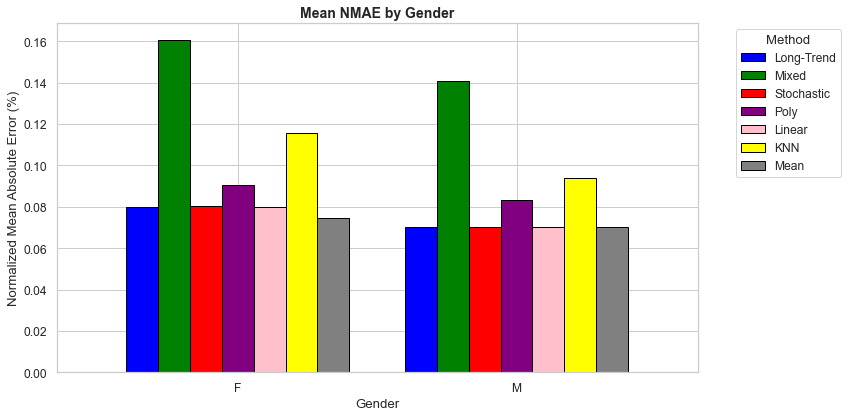

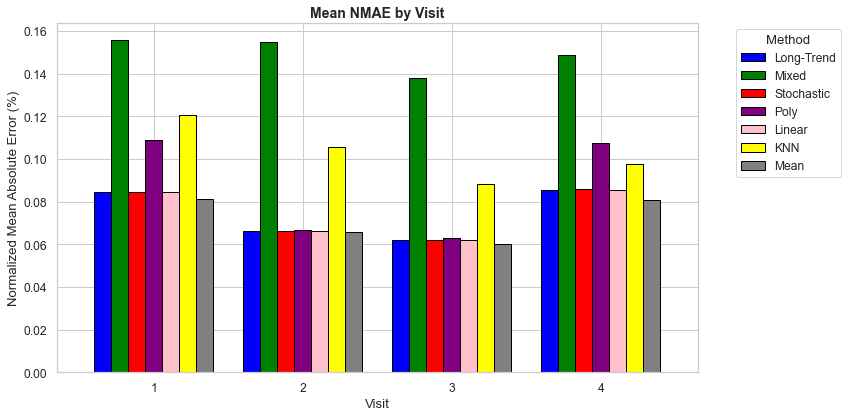

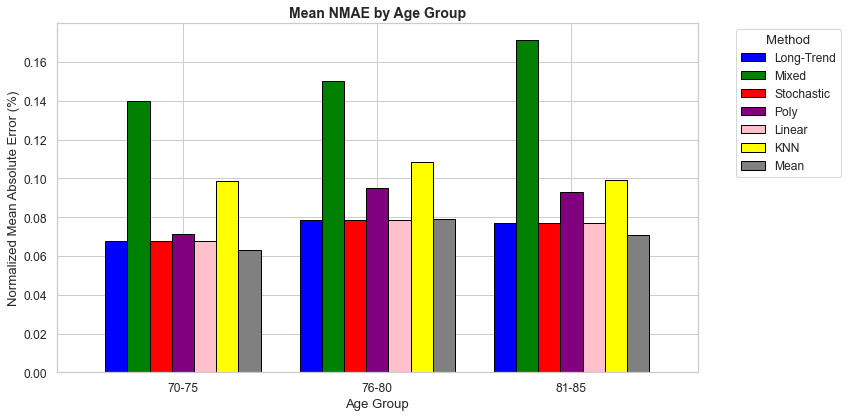

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
#Set-up of list of models

models = {
    'KNN': [df_knn_10, df_knn_20, df_knn_30],
    'Linear': [df_linear_10, df_linear_20, df_linear_30],
    'Poly': [df_poly_10, df_poly_20, df_poly_30],
    'Mixed': [df_mixed_10, df_mixed_20, df_mixed_30],
    'Mean': [df_mean_10, df_mean_20, df_mean_30],
    'Stochastic': [df_stochastic_10, df_stochastic_20, df_stochastic_30],
    'Long-Trend': [df_trend_10, df_trend_20, df_trend_30]
}
masks = [masked_cells_10, masked_cells_20, masked_cells]
levels = ['10%', '20%', '30%']

all_records = []
numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
col_ranges = df[numeric_cols].max() - df[numeric_cols].min()

for name, dfs in models.items():
    for d_imp, m_cells, lvl in zip(dfs, masks, levels):
        for row, col in m_cells:
            if col in numeric_cols:
                true_v, imp_v = df.loc[row, col], d_imp.loc[row, col]
                if pd.notna(true_v):
                    all_records.append({
                        'Method': name, 'Level': lvl, 
                        'NMAE': abs(true_v - imp_v) / (col_ranges[col] or 1),
                        'Gender': df.loc[row, 'gender'], 
                        'Visit': df.loc[row, 'clinical_visit'],
                        'Age': df.loc[row, 'age']
                    })

#Master data of all NMAE for each method
df_master = pd.DataFrame(all_records)
df_master['Age Group'] = pd.cut(df_master['Age'], bins=[70, 76, 81, 86], labels=['70-75', '76-80', '81-85'], right=False)

sns.set(style="whitegrid", font_scale=1.1)

colours = ['blue', 'green', 'red', 'purple', 'pink', 'yellow', 'grey']
cols_order = ['Long-Trend', 'Mixed', 'Stochastic', 'Poly', 'Linear', 'KNN', 'Mean']
#Plot
for col_name in ['Gender', 'Visit', 'Age Group']:
    plt.figure(figsize=(12, 6))
    
    plot_data = df_master.groupby([col_name, 'Method'])['NMAE'].mean().unstack()[cols_order]
    
    ax = plot_data.plot(kind='bar', ax=plt.gca(), width=0.8, edgecolor='black', color= colours)
    
    plt.title(f'Mean NMAE by {col_name}', fontweight='bold', fontsize=14)
    plt.ylabel('Normalized Mean Absolute Error (%)')
    plt.xlabel(col_name)
    
    plt.xticks(rotation=0)
    
    plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

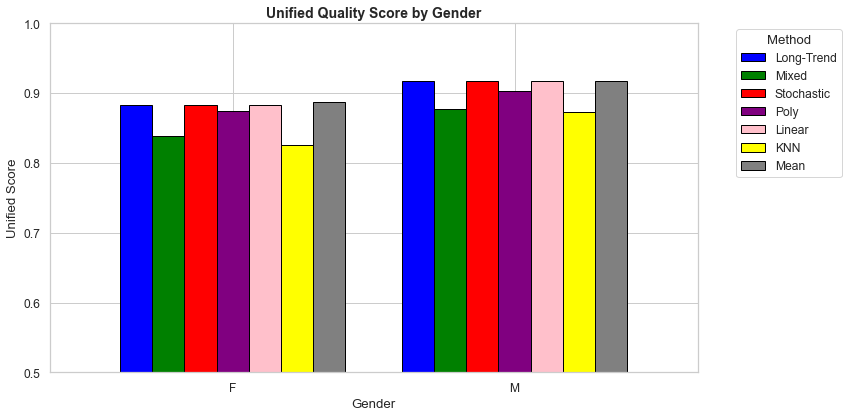

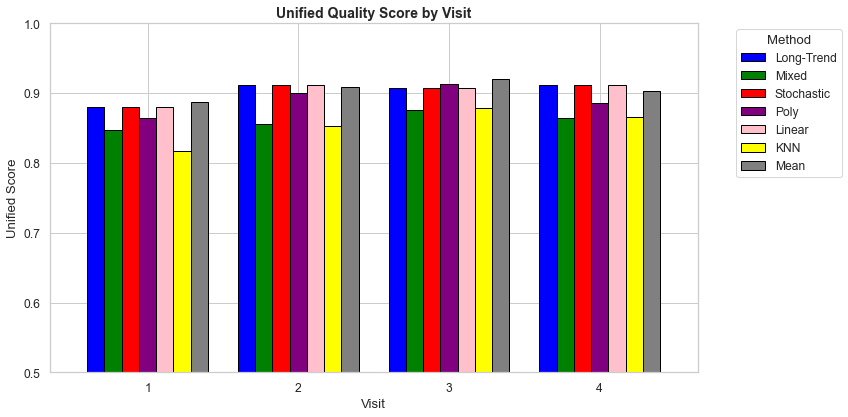

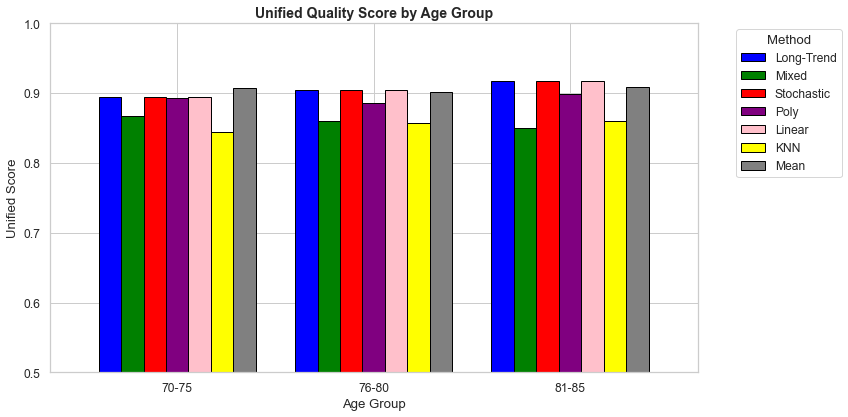


=== FINAL RANKING: UNIFIED QUALITY SCORE ===
Method
Mean          0.9049
Long-Trend    0.9030
Linear        0.9030
Stochastic    0.9030
Poly          0.8906
Mixed         0.8606
KNN           0.8533
dtype: float64


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Set-up
all_unified_results = []
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.difference(['part_id', 'q_date'])

for name, dfs in models.items():
    for d_imp, m_cells, lvl in zip(dfs, masks, levels):
        records = []
        for row, col in m_cells:
            true_v, imp_v = df.loc[row, col], d_imp.loc[row, col]
            if pd.isna(true_v): continue
            
            meta = {
                'Method': name, 'Level': lvl, 
                'Gender': df.loc[row, 'gender'], 
                'Visit': df.loc[row, 'clinical_visit'], 
                'Age': df.loc[row, 'age']
            }
            
            if col in numeric_cols:
                denom = col_ranges[col] if col_ranges[col] != 0 else 1
                score = 1 - (abs(true_v - imp_v) / denom)
                records.append({**meta, 'Metric_Type': 'Numeric', 'Score': score})
            else:
                score = 1 if str(true_v) == str(imp_v) else 0
                records.append({**meta, 'Metric_Type': 'Categorical', 'Score': score})
        
        all_unified_results.append(pd.DataFrame(records))

df_master_unified = pd.concat(all_unified_results, ignore_index=True)
df_master_unified['Age Group'] = pd.cut(df_master_unified['Age'], bins=[70, 76, 81, 86], labels=['70-75', '76-80', '81-85'], right=False)

#Getting unified score
def get_unified_score(group):
    type_means = group.groupby('Metric_Type')['Score'].mean()
    return type_means.mean()

for col_name in ['Gender', 'Visit', 'Age Group']:
    plt.figure(figsize=(12, 6))
    

    plot_data = df_master_unified.groupby([col_name, 'Method']).apply(get_unified_score).unstack()[cols_order]
    
    ax = plot_data.plot(kind='bar', ax=plt.gca(), width=0.8, edgecolor='black', color=colours)
    
    plt.title(f'Unified Quality Score by {col_name}', fontweight='bold', fontsize=14)
    plt.ylabel('Unified Score')
    plt.xlabel(col_name)
    plt.ylim(0.5, 1.0)
    
    plt.xticks(rotation=0)
    
    plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

print("\n=== FINAL RANKING: UNIFIED QUALITY SCORE ===")
final_unified_rank = df_master_unified.groupby('Method').apply(get_unified_score).sort_values(ascending=False)
print(final_unified_rank.round(4))

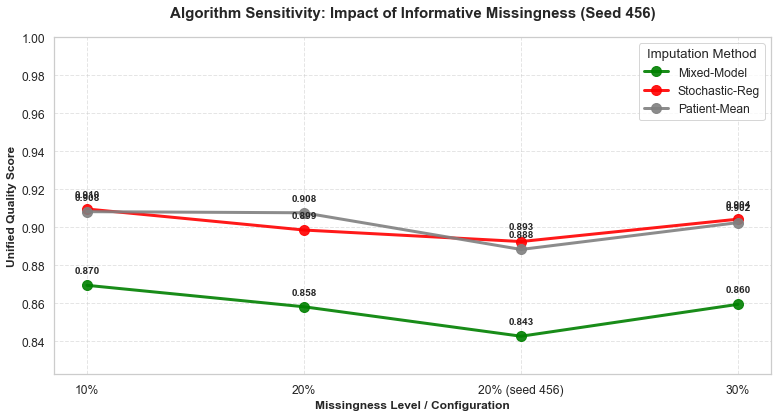

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Set-up
summary_list = []
all_summaries = {
    'Mixed-Model': mixed_summary,
    'Stochastic-Reg': stochastic_summary,
    'Patient-Mean': mean_summary
}

for method_name, results in all_summaries.items():
    for level, score in results.items():
        summary_list.append({
            'Method': method_name,
            'Missingness': level,
            'Score': score
        })

df_stress = pd.DataFrame(summary_list)

#Setting order
order = ["10%", "20%", "20% (seed 456)", "30%"]
df_stress['Missingness'] = pd.Categorical(df_stress['Missingness'], categories=order, ordered=True)

#Visualisation
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

palette = {'Mixed-Model': 'green', 'Stochastic-Reg': 'red', 'Patient-Mean': 'gray'}
markers = {'Mixed-Model': 'D', 'Stochastic-Reg': 's', 'Patient-Mean': 'o'}

for method in all_summaries.keys():
    subset = df_stress[df_stress['Method'] == method].sort_values('Missingness')
    plt.plot(subset['Missingness'], subset['Score'], 
             label=method, 
             marker="o", 
             color=palette[method], 
             linewidth=3, 
             markersize=10, 
             alpha=0.9)

plt.title('Algorithm Sensitivity: Impact of Informative Missingness (Seed 456)', 
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Unified Quality Score', fontsize=12, fontweight='bold')
plt.xlabel('Missingness Level / Configuration', fontsize=12, fontweight='bold')

plt.ylim(df_stress['Score'].min() - 0.02, 1.0)

#Labels
for i, row in df_stress.iterrows():
    plt.annotate(f"{row['Score']:.3f}", 
                 (row['Missingness'], row['Score']),
                 textcoords="offset points", 
                 xytext=(0, 12), 
                 ha='center', 
                 fontsize=10, 
                 fontweight='bold')

plt.legend(title="Imputation Method", loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/var/folders/rg/05k7hb1x1bx26g_d7t1jmzww0000gn/T/ipykernel_77112/3502021654.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])


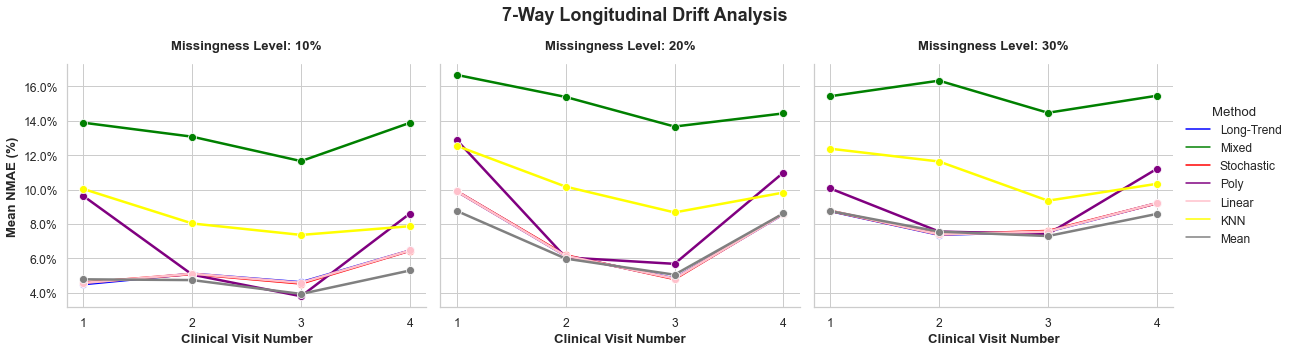


=== MODEL STABILITY RANKING (NMAE STD DEV) ===
Method
Mean          0.15328
KNN           0.15365
Long-Trend    0.16083
Linear        0.16120
Stochastic    0.16127
Mixed         0.16779
Poly          0.17816
Name: NMAE, dtype: float64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Plot of NMAE at each missingness level at every visit number.

all_drift_records = []
numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])

for name, dfs in models.items():
    for d_imp, m_cells, lvl in zip(dfs, masks, levels):
        for row, col in m_cells:
            if col in numeric_cols:
                true_v, imp_v = df.loc[row, col], d_imp.loc[row, col]
                if pd.notna(true_v):
                    all_drift_records.append({
                        'Method': name, 'Level': lvl, 
                        'Visit': df.loc[row, 'clinical_visit'],
                        'NMAE': abs(true_v - imp_v) / (col_ranges[col] or 1)
                    })

df_drift = pd.DataFrame(all_drift_records)

g = sns.relplot(
    data=df_drift,
    x="Visit", y="NMAE", hue="Method", col="Level",
    hue_order=cols_order,
    palette=colours,
    kind="line", 
    marker="o",
    ci=None,
    linewidth=2.5,
    markersize=8,
    height=5, aspect=1.1,
    facet_kws={'sharey': True}
)

g.set_axis_labels("Clinical Visit Number", "Mean NMAE (%)", fontweight='bold')
g.set_titles("Missingness Level: {col_name}", fontweight='bold', pad=15)

plt.subplots_adjust(top=0.82)
g.fig.suptitle('7-Way Longitudinal Drift Analysis', fontsize=18, fontweight='bold')

for ax in g.axes.flat:
    visits = sorted(df_drift['Visit'].unique())
    ax.set_xticks(visits)
    ax.set_xticklabels(visits, rotation=0)

    vals = ax.get_yticks()
    ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])

plt.show()
print("\n=== MODEL STABILITY RANKING (NMAE STD DEV) ===")
stability = df_drift.groupby('Method')['NMAE'].std().sort_values()
print(stability.round(5))

/var/folders/rg/05k7hb1x1bx26g_d7t1jmzww0000gn/T/ipykernel_77112/3735076137.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.3f}'.format(x) for x in vals])


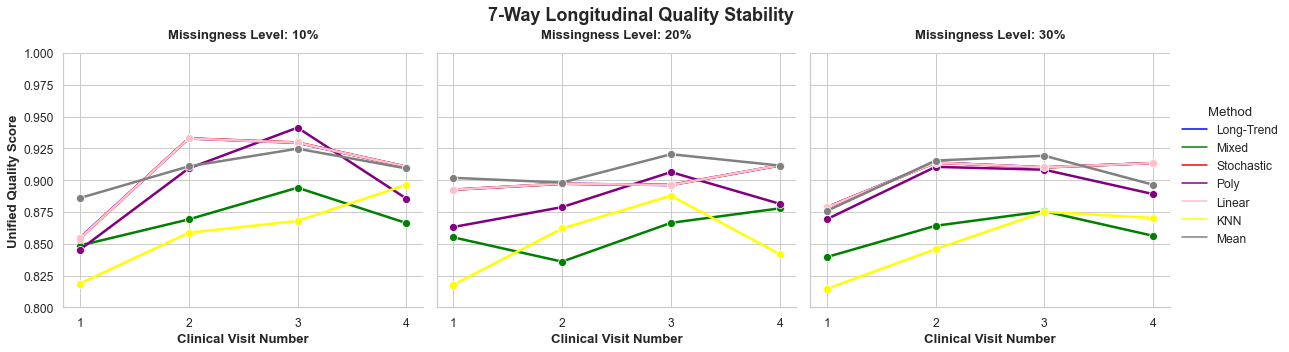

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#plot to show UQS at each missingness level at each visit number.

all_drift_records = []
numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['part_id', 'clinical_visit'])
col_ranges = df[numeric_cols].max() - df[numeric_cols].min()

for name, dfs in models.items():
    for d_imp, m_cells, lvl in zip(dfs, masks, levels):
        records = []
        for row, col in m_cells:
            true_v, imp_v = df.loc[row, col], d_imp.loc[row, col]
            if pd.isna(true_v): continue
            
            visit = df.loc[row, 'clinical_visit']
            
            if col in numeric_cols:
                score = 1 - (abs(true_v - imp_v) / (col_ranges[col] or 1))
                records.append({'Method': name, 'Level': lvl, 'Visit': visit, 'Type': 'Num', 'Score': score})
            else:
                score = 1 if str(true_v) == str(imp_v) else 0
                records.append({'Method': name, 'Level': lvl, 'Visit': visit, 'Type': 'Cat', 'Score': score})
        
        if records:
            all_drift_records.append(pd.DataFrame(records))

df_drift_master = pd.concat(all_drift_records, ignore_index=True)

def get_visit_score(group):
    return group.groupby('Type')['Score'].mean().mean()

drift_plot_data = df_drift_master.groupby(['Level', 'Method', 'Visit']).apply(get_visit_score).reset_index(name='Unified_Score')

g = sns.relplot(
    data=drift_plot_data,
    x="Visit", y="Unified_Score", hue="Method", col="Level",
    hue_order=cols_order,
    palette=colours,
    kind="line", 
    marker="o",
    ci=None,
    linewidth=2.5,
    markersize=8,
    height=5, aspect=1.1,
    facet_kws={'sharey': True}
)

g.set_axis_labels("Clinical Visit Number", "Unified Quality Score", fontweight='bold')
g.set_titles("Missingness Level: {col_name}", fontweight='bold', pad=15)
plt.subplots_adjust(top=.85)
g.fig.suptitle('7-Way Longitudinal Quality Stability', 
               fontsize=18, fontweight='bold')

for ax in g.axes.flat:
    ax.set_xticks(sorted(drift_plot_data['Visit'].unique()))
    ax.set_xticklabels(ax.get_xticks(), rotation=0)
    
    ax.set_ylim(0.8, 1.0) 
    vals = ax.get_yticks()
    ax.set_yticklabels(['{:.3f}'.format(x) for x in vals])

plt.show()

In [28]:
#Filter for categorical variables only
df_cat = df_master_unified[df_master_unified['Metric_Type'] == 'Categorical']

#mean of 0 and 1 gives categorical accuracy
accuracy_table = df_cat.groupby(['Method', 'Level'])['Score'].mean().unstack()


level_order = ['10%', '20%', '30%']
accuracy_table = accuracy_table[level_order]

#reorder accuracy
cat_rank = df_cat.groupby('Method')['Score'].mean().sort_values(ascending=False).index
accuracy_table = accuracy_table.reindex(cat_rank)


print("Categorical Accuracy")

# Apply percentage formatting
formatted_cat_table = (accuracy_table * 100).round(2).applymap(lambda x: f"{x}%")
print(formatted_cat_table)


Categorical Accuracy
Level          10%     20%     30%
Method                            
Mean        86.33%  88.61%  88.54%
Linear      87.05%  87.07%  89.08%
Long-Trend  87.05%  87.07%  89.08%
Stochastic  87.05%  87.07%  89.08%
Mixed       87.05%  86.68%  87.33%
Poly        85.97%  85.33%  88.01%
KNN         80.58%  80.89%  81.27%


In [29]:
#Only numerical variables
df_num = df_master_unified[df_master_unified['Metric_Type'] == 'Numeric'].copy()

#NMAE by level of missingness and method.
nmae_table = df_num.groupby(['Method', 'Level'])['Score'].mean().unstack()

level_order = ['10%', '20%', '30%']
available_levels = [l for l in level_order if l in nmae_table.columns]
nmae_table = nmae_table[available_levels]

num_rank = nmae_table.mean(axis=1).sort_values().index
nmae_table = nmae_table.reindex(num_rank)

print("Numerical NMAE")

formatted_num_table = (nmae_table * 100).round(3).applymap(lambda x: f"{x:.3f}%" if pd.notna(x) else "N/A")
print(formatted_num_table)


Numerical NMAE
Level           10%      20%      30%
Method                               
Mixed       86.857%  84.962%  84.571%
KNN         91.614%  89.698%  89.016%
Poly        93.209%  91.121%  90.989%
Stochastic  94.881%  92.652%  91.781%
Linear      94.867%  92.662%  91.786%
Long-Trend  94.881%  92.659%  91.801%
Mean        95.320%  92.923%  91.955%


/var/folders/rg/05k7hb1x1bx26g_d7t1jmzww0000gn/T/ipykernel_77112/222801351.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.3f}'.format(x) for x in vals])


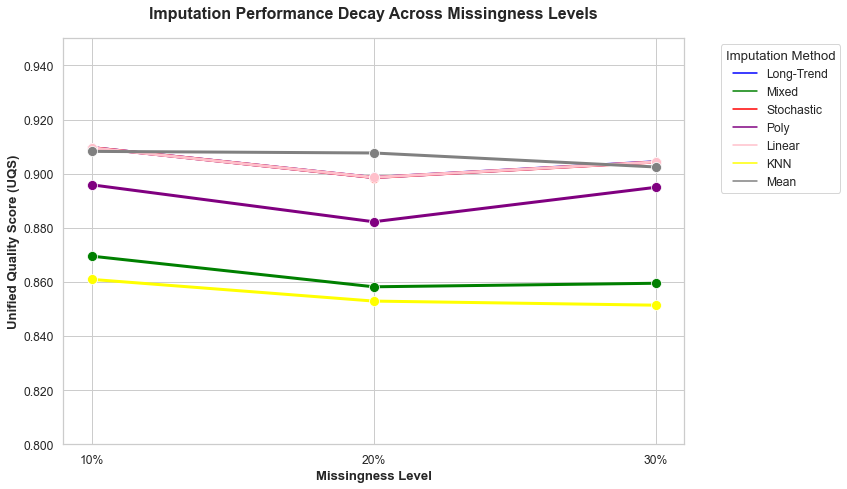

In [ ]:
single_plot_data = df_drift_master.groupby(['Level', 'Method']).apply(get_visit_score).reset_index(name='Unified_Score')

single_plot_data['Level'] = pd.Categorical(single_plot_data['Level'], categories=['10%', '20%', '30%'], ordered=True)

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid", font_scale=1.1)

sns.lineplot(
    data=single_plot_data,
    x="Level", 
    y="Unified_Score", 
    hue="Method", 
    hue_order=cols_order,
    palette=colours,
    marker="o",
    markersize=10,
    linewidth=3,
    
)

plt.title('Imputation Performance Decay Across Missingness Levels', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Missingness Level', fontweight='bold')
plt.ylabel('Unified Quality Score (UQS)', fontweight='bold')

plt.ylim(0.8, 0.95) 

ax = plt.gca()
vals = ax.get_yticks()
ax.set_yticklabels(['{:.3f}'.format(x) for x in vals])

plt.legend(title="Imputation Method", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()